# check  cdr RMSD 

### 각 pdb별 샘플들의 h3 cdr RMSD 분포 체크

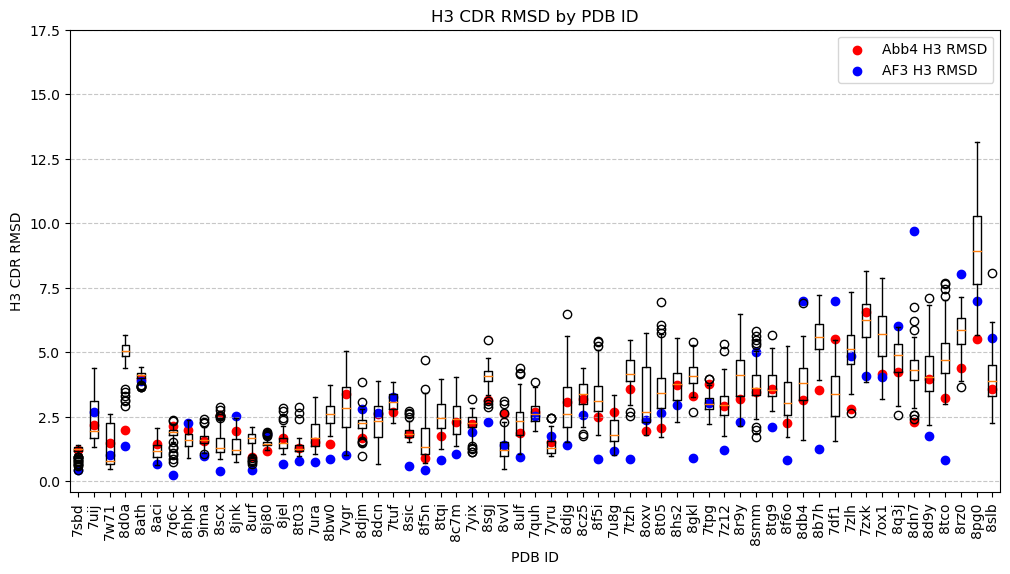

In [26]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd

pred_dir = "/home/psh/protein-frame-flow/inference_outputs/all_atom_framePred_sample_anchor/2025-03-18_14-08-21/last/run_2025-03-20_16-56-17"
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/project_v2/final_output/af3/only_cdr'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 이전 프로젝트에서 RMSD 값 불러오기
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        h3_rmsd_by_pdb_prev[pdb_key] = prev_data['h3_rms']
    else:
        h3_rmsd_by_pdb_prev[pdb_key] = 5.5  # 기본값 설정

    # af3에서 RMSD 값 불러오기 
    af3_filepath = os.path.join(af3_dir, pdb_id + '.json')
    if os.path.exists(af3_filepath):
        with open(af3_filepath, 'r') as f:
            af3_data = json.load(f)
        h3_rmsd_by_pdb_af3[pdb_key] = af3_data['h3_rms']
    else:
        h3_rmsd_by_pdb_af3[pdb_key] = 7.0  # 기본값 설정

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
pdb_names_sorted = df_sorted["pdb_name"].tolist()
pdb_names_sorted = [filename.split('_')[0] for filename in pdb_names_sorted]
# 📌 정렬된 순서로 RMSD 값을 가져오기
h3_rmsd_sorted = [h3_rmsd_by_pdb.get(pdb, []) for pdb in pdb_names_sorted]  # 데이터 없는 경우 빈 리스트 처리
prev_values_sorted = [h3_rmsd_by_pdb_prev.get(pdb, None) for pdb in pdb_names_sorted]
af3_values_sorted = [h3_rmsd_by_pdb_af3.get(pdb, None) for pdb in pdb_names_sorted]

# 📌 그래프 그리기
plt.figure(figsize=(12, 6))
plt.boxplot(h3_rmsd_sorted, labels=pdb_names_sorted)

# 🔹 이전 프로젝트 및 AF3 RMSD 값 표시
plt.scatter(range(1, len(pdb_names_sorted) + 1), prev_values_sorted, color='red', marker='o', label="Abb4 H3 RMSD")
plt.scatter(range(1, len(pdb_names_sorted) + 1), af3_values_sorted, color='blue', marker='o', label="AF3 H3 RMSD")

# 그래프 설정
plt.xlabel("PDB ID")
plt.ylabel("H3 CDR RMSD")
plt.xticks(rotation=90)  # PDB ID가 많을 경우 가독성을 위해 회전
plt.title("H3 CDR RMSD by PDB ID")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.yticks([0.0, 2.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5])
# 그래프 표시
plt.show()

## 각 pdb에서 상위 10위 추출

In [23]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import json
import os 

pred_dir = "/home/psh/protein-frame-flow/inference_outputs/all_atom_framePred_sample_anchor/2025-03-18_14-08-21/last/run_2025-03-20_16-56-17"
select_rank = 25

h3_rmsd_by_pdb = {}
pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가


    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  

top_10_rmsd_by_pdb = {}

for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[select_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

2.664059872220343


### 각 모델 별 rmsd 비교 

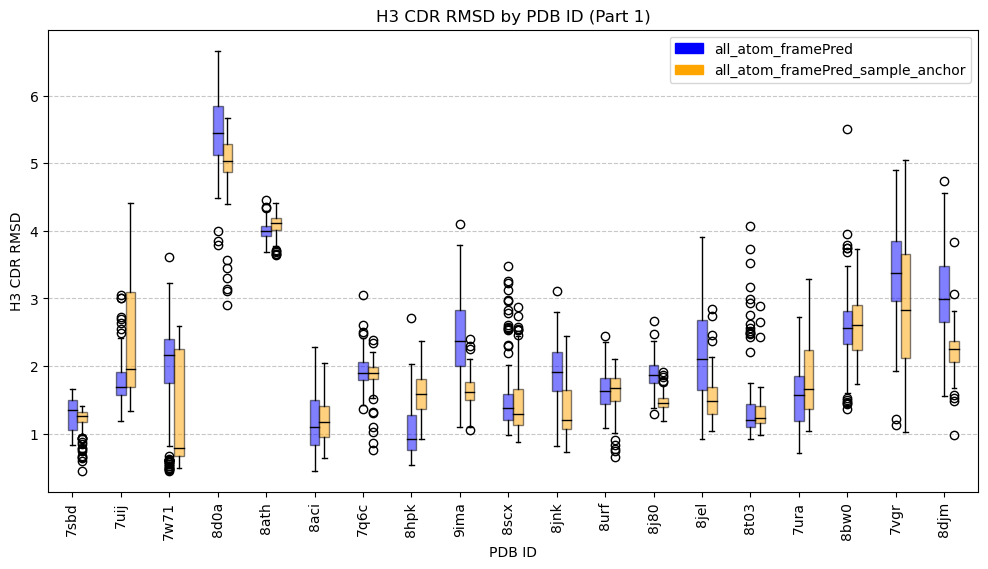

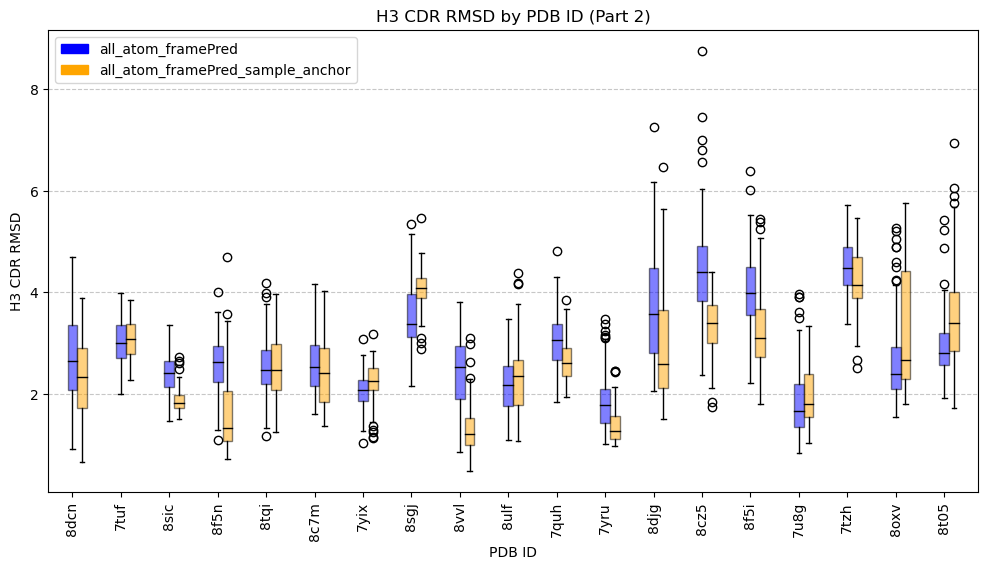

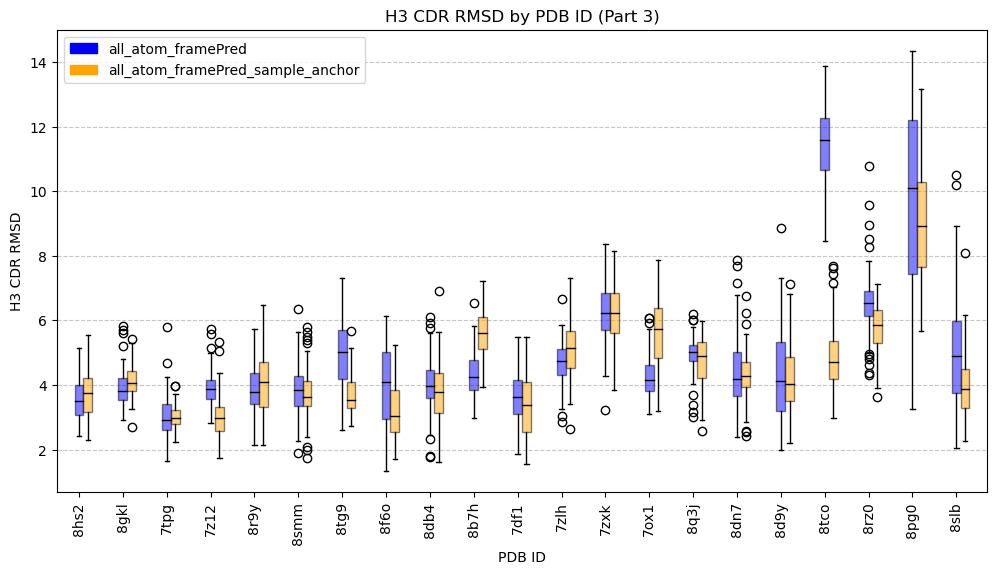

In [11]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

pred_dirs = [
    "/home/psh/protein-frame-flow/inference_outputs/all_atom_framePred/2025-03-13_11-39-53/last/run_2025-03-16_11-50-24",
    "/home/psh/protein-frame-flow/inference_outputs/all_atom_framePred_sample_anchor/2025-03-18_14-08-21/last/run_2025-03-20_16-56-17"
]

prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/project_v2/final_output/af3/only_cdr'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 이전 프로젝트에서 RMSD 값 불러오기
        if pdb_key not in h3_rmsd_by_pdb_prev:
            prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
            if os.path.exists(prev_filepath):
                with open(prev_filepath, 'r') as f:
                    prev_data = json.load(f)
                h3_rmsd_by_pdb_prev[pdb_key] = prev_data['h3_rms']
            else:
                h3_rmsd_by_pdb_prev[pdb_key] = 5.5  # 기본값 설정

        # af3에서 RMSD 값 불러오기 
        if pdb_key not in h3_rmsd_by_pdb_af3:
            af3_filepath = os.path.join(af3_dir, pdb_id + '.json')
            if os.path.exists(af3_filepath):
                with open(af3_filepath, 'r') as f:
                    af3_data = json.load(f)
                h3_rmsd_by_pdb_af3[pdb_key] = af3_data['h3_rms']
            else:
                h3_rmsd_by_pdb_af3[pdb_key] = 4.5  # 기본값 설정

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
sorted_pdb_ids = df_sorted["pdb_name"].tolist()
sorted_pdb_ids = [filename.split('_')[0] for filename in sorted_pdb_ids if filename.split('_')[0] in all_pdb_ids]

# PDB ID를 3등분
num_splits = 3
split_size = len(sorted_pdb_ids) // num_splits
split_pdb_ids = [sorted_pdb_ids[i * split_size:(i + 1) * split_size] for i in range(num_splits - 1)]
split_pdb_ids.append(sorted_pdb_ids[(num_splits - 1) * split_size:])  # 마지막 부분 추가

# 색상 설정
colors = ['blue', 'orange']
handles = [mpatches.Patch(color=colors[idx], label=dir.split('/')[5]) for idx, dir in enumerate(pred_dirs)]

# 📌 그래프 그리기 (3개로 분할)
for i, pdb_subset in enumerate(split_pdb_ids):
    plt.figure(figsize=(12, 6))

    for idx, pred_dir in enumerate(pred_dirs):
        h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in pdb_subset]
        plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(pdb_subset)) + (idx * 0.2), widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[idx], alpha=0.5), medianprops=dict(color='black'))


    # 그래프 설정
    plt.xlabel("PDB ID")
    plt.ylabel("H3 CDR RMSD")
    plt.xticks(range(len(pdb_subset)), pdb_subset, rotation=90)
    plt.title(f"H3 CDR RMSD by PDB ID (Part {i+1})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(handles=handles)
    # 그래프 표시
    plt.show()


In [1]:
import os 
import re
import shutil 

def convert_to_uppercase(text):
    return re.sub(r'_(\w)', lambda x: '_' + x.group(1).upper(), text)

pred_dir = '/home/psh/af3_output'
target_root_dir = '/home/psh/af3_output'

os.makedirs(target_root_dir, exist_ok=True)

for file in os.listdir(pred_dir):
    file_dir = os.path.join(pred_dir, file)
    file_upper = convert_to_uppercase(file)
    target_file_dir = os.path.join(target_root_dir, file_upper)

    for i, sample in enumerate(os.listdir(file_dir)):
        target_dir = os.path.join(target_file_dir, f'sample_{i}')
        os.makedirs(target_dir, exist_ok=True)
        target_path = os.path.join(target_dir, 'sample_1.pdb')

        src_filepath = os.path.join(file_dir, sample)
        shutil.copy(src_filepath, target_path)

In [4]:
import os 
import shutil 
pred_dir = '/home/psh/af3_output'


for file in os.listdir(pred_dir):
    file_dir = os.path.join(pred_dir, file)
    if not file.split('_')[1].isupper():
        shutil.rmtree(file_dir)